In [1]:
import os
import sys
import numpy as np

root_path = os.path.abspath(os.path.join('..'))
if root_path not in sys.path:
    sys.path.append(root_path)
 
from syn_project.utils_train import *
from syn_project.utils_color_analysis import *

%matplotlib widget

In [2]:
project_name = "syn"
condition = "test"
data = "biased_80"
switch_epoch = 300
checkpoint_epoch = 300

n_samples_test = 1000
show_results_fusion = True
fusion_attr_weight = 1.0
noise = 0.0

experiment_name = get_experiment_name(condition, data, switch_epoch)
cat_names=CAT_NAMES

training_params = get_training_params(project_name, experiment_name)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

global_workspace = get_global_workspace(project_name, experiment_name, epoch=checkpoint_epoch)
data_module = get_data_module(project_name,  experiment_name)
test_samples = get_data_samples(data_module, n_samples_test, noise=  noise, split= "test")
data_translated = get_data_translated(global_workspace, test_samples, n_samples_test)

data_dir = f"{ROOT_PATH}/checkpoints/{project_name}/{experiment_name}/checkpoints"
files = load_epoch_files(data_dir)
epochs, color_history = get_color_data_from_epoch_files(files)


/home/lucas/.cache/pypoetry/virtualenvs/alexis-n7zQ69N0-py3.11/lib/python3.11/site-packages/lightning/fabric/utilities/cloud_io.py:73: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.


Loading model from checkpoint: /home/lucas/gwsyn/checkpoints/syn/test_biased_80_switch_300/checkpoints/save-epoch=300.ckpt
Loaded default weights from /home/lucas/gwsyn/checkpoints/syn/test_biased_80_switch_300/checkpoints/save-epoch=300.ckpt


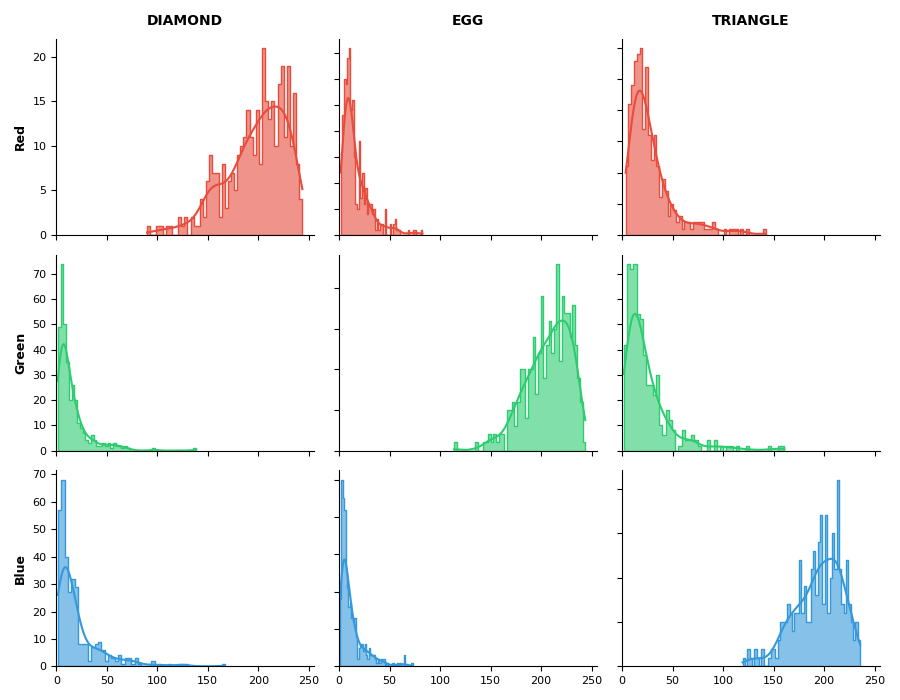

In [3]:
plot_color = "decoded"

masks = get_mask_from_shapes(data_translated["train_images"])
masks_decoded = get_mask_from_shapes(data_translated["images_decoded"])

colors_from_training_img = get_color_from_images(data_translated["train_images"], masks)
colors_from_decoded_img = get_color_from_images(data_translated["images_decoded"], masks_decoded)

categories_from_training_attr = data_translated['train_attr'][:, 0:3]
categories_from_decoded_attr = categorize_decoded_attr(data_translated["attr_decoded"])

categories_indices = categories_from_decoded_attr.argmax(dim=1).detach().cpu().numpy()

colors_np = np.vstack(colors_from_training_img)
if plot_color == "decoded":
    colors_np = np.vstack(colors_from_decoded_img)

fig = plot_rgb_distribution(colors_np, categories_indices, n_bins=50)
plt.show()


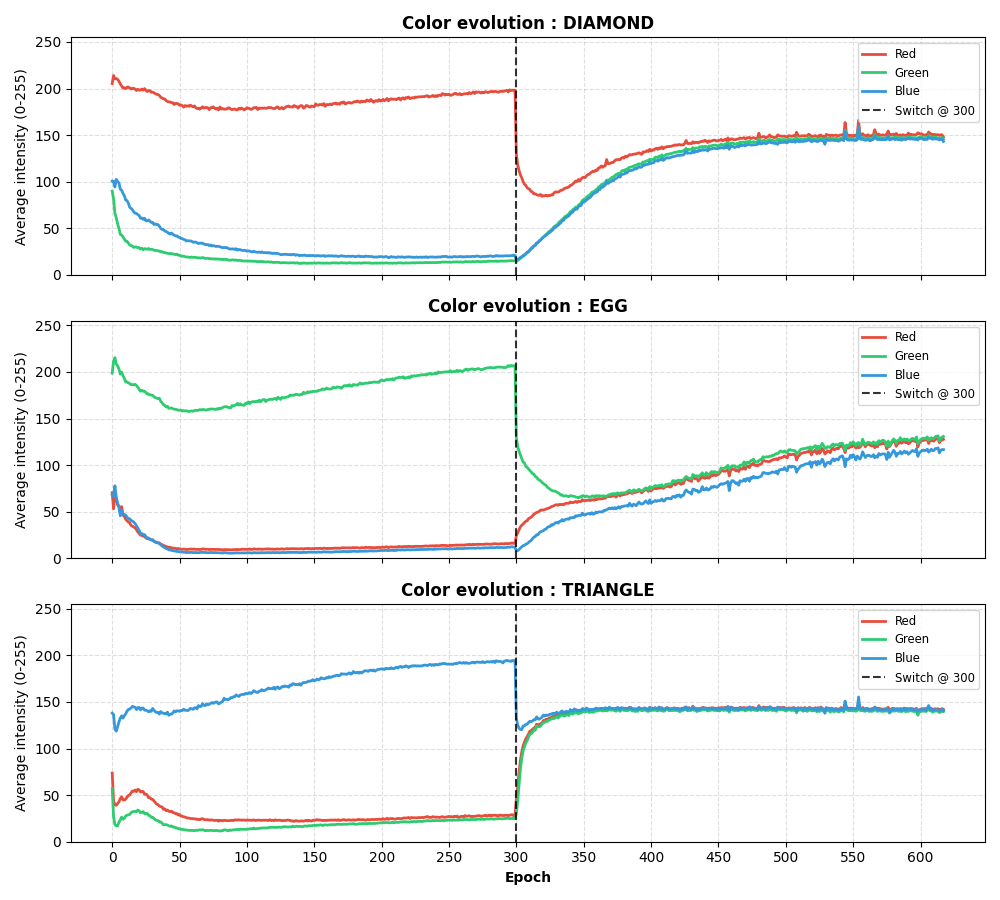

In [4]:
fig = plot_color_evolution_per_category(data_dir, CAT_NAMES, vline_epoch=switch_epoch)
plt.show()


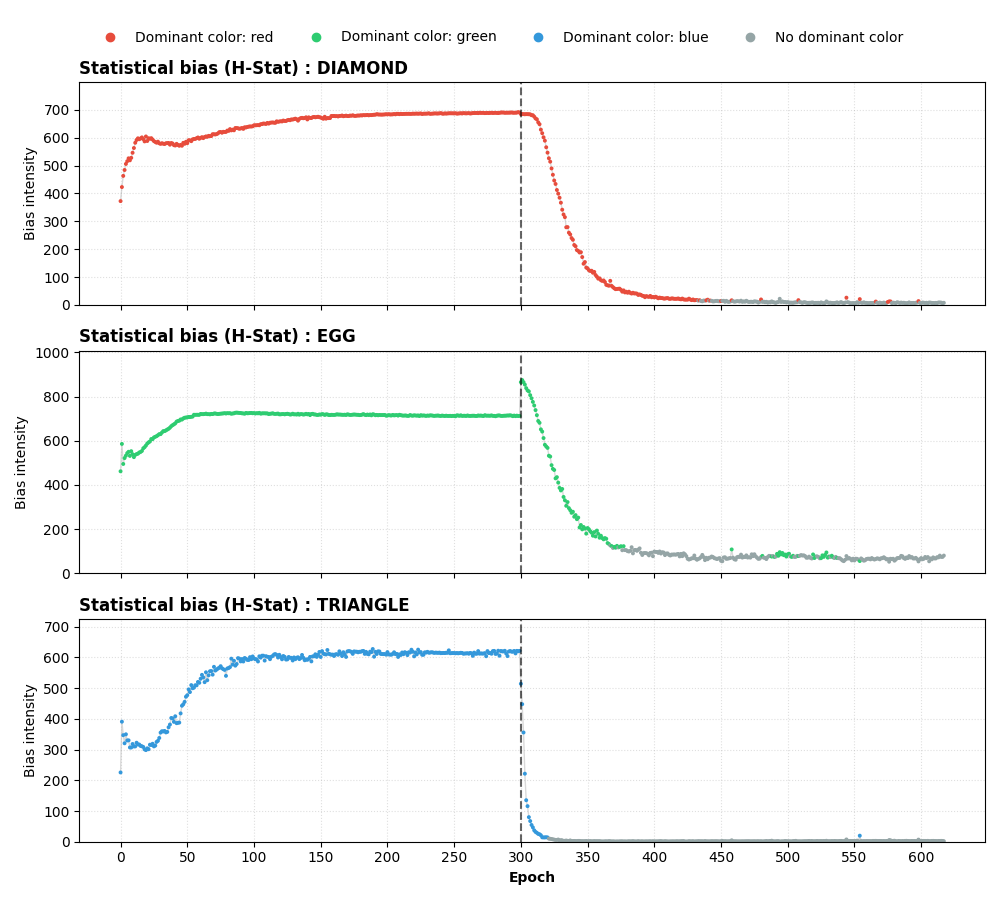

In [5]:

color_statisitical_dominance = color_statisitical_dominance_analysis(data_dir)
fig = plot_statistical_dominance_evolution(color_statisitical_dominance, cat_names=cat_names, vline_epoch=switch_epoch)

plt.show()

In [6]:
import os
import re
from IPython.display import display, Image
import ipywidgets as widgets

def interactive_epoch_viewer(data_dir: str):
    # 1. Récupération et tri des fichiers par numéro d'époque
    files = [f for f in os.listdir(data_dir) if f.startswith("fig_comparison_epoch_") and f.endswith(".png")]
    
    # Extraction du numéro d'époque pour un tri numérique correct
    def extract_epoch(filename: str) -> int:
        # On utilise \d+ pour capturer les chiffres (digits)
        match = re.search(r'epoch_(\d+)', filename)
        return int(match.group(1)) if match else 0

    files.sort(key=extract_epoch)
    epochs = [extract_epoch(f) for f in files]

    if not files:
        print("Aucune image trouvée dans le dossier.")
        return

    # 2. Création du widget Slider
    slider = widgets.IntSlider(
        value=epochs[0],
        min=min(epochs),
        max=max(epochs),
        step=epochs[1] - epochs[0] if len(epochs) > 1 else 1,
        description='Epoch:',
        layout=widgets.Layout(width='80%'),
        continuous_update=False  # Évite de charger toutes les images pendant qu'on glisse
    )

    # 3. Fonction d'affichage
    def update_display(epoch):
        filename = f"fig_comparison_epoch_{epoch:03d}.png"
        filepath = os.path.join(data_dir, filename)
        
        if os.path.exists(filepath):
            display(Image(filename=filepath))
        else:
            print(f"Image pour l'époque {epoch} non trouvée.")

    # 4. Connexion du slider à la fonction
    widgets.interact(update_display, epoch=slider)

# --- Utilisation ---
interactive_epoch_viewer(data_dir + "/visual_logs")

interactive(children=(IntSlider(value=0, continuous_update=False, description='Epoch:', layout=Layout(width='8…